In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
#from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.colors as colors

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
def setup_figure():
    gs = fig.add_gridspec(4,10)

    # d4pdf axes
    d4pdf_sf_axs = []
    d4pdf_map_axs = []
    for i in range(4):
        ax = fig.add_subplot(gs[i, 0])
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_xticks([])
        d4pdf_sf_axs.append(ax)

        ax = fig.add_subplot(gs[i, 1:5], projection=ccrs.PlateCarree())
        ax.coastlines(resolution='auto', color='k')
        ax.set_extent([232.5,255, 32.5,54.18], crs=ccrs.PlateCarree())

        d4pdf_map_axs.append(ax)


    # cam5 scaling factor axes
    cam5_sf_axs = []
    cam5_map_axs = []
    for i in range(4):
        ax = fig.add_subplot(gs[i, 5])
        plt.setp(ax.get_yticklabels(), visible=False)
        ax.set_xticks([])
        plt.setp(ax.get_xticklabels(), visible=False)
        cam5_sf_axs.append(ax)

        ax = fig.add_subplot(gs[i, 6:10], projection=ccrs.PlateCarree())
        ax.coastlines(resolution='auto', color='k')
        ax.set_extent([232.5,255, 32.5,54.18], crs=ccrs.PlateCarree())

        cam5_map_axs.append(ax)
        
    return(d4pdf_sf_axs,d4pdf_map_axs,cam5_sf_axs,cam5_map_axs)


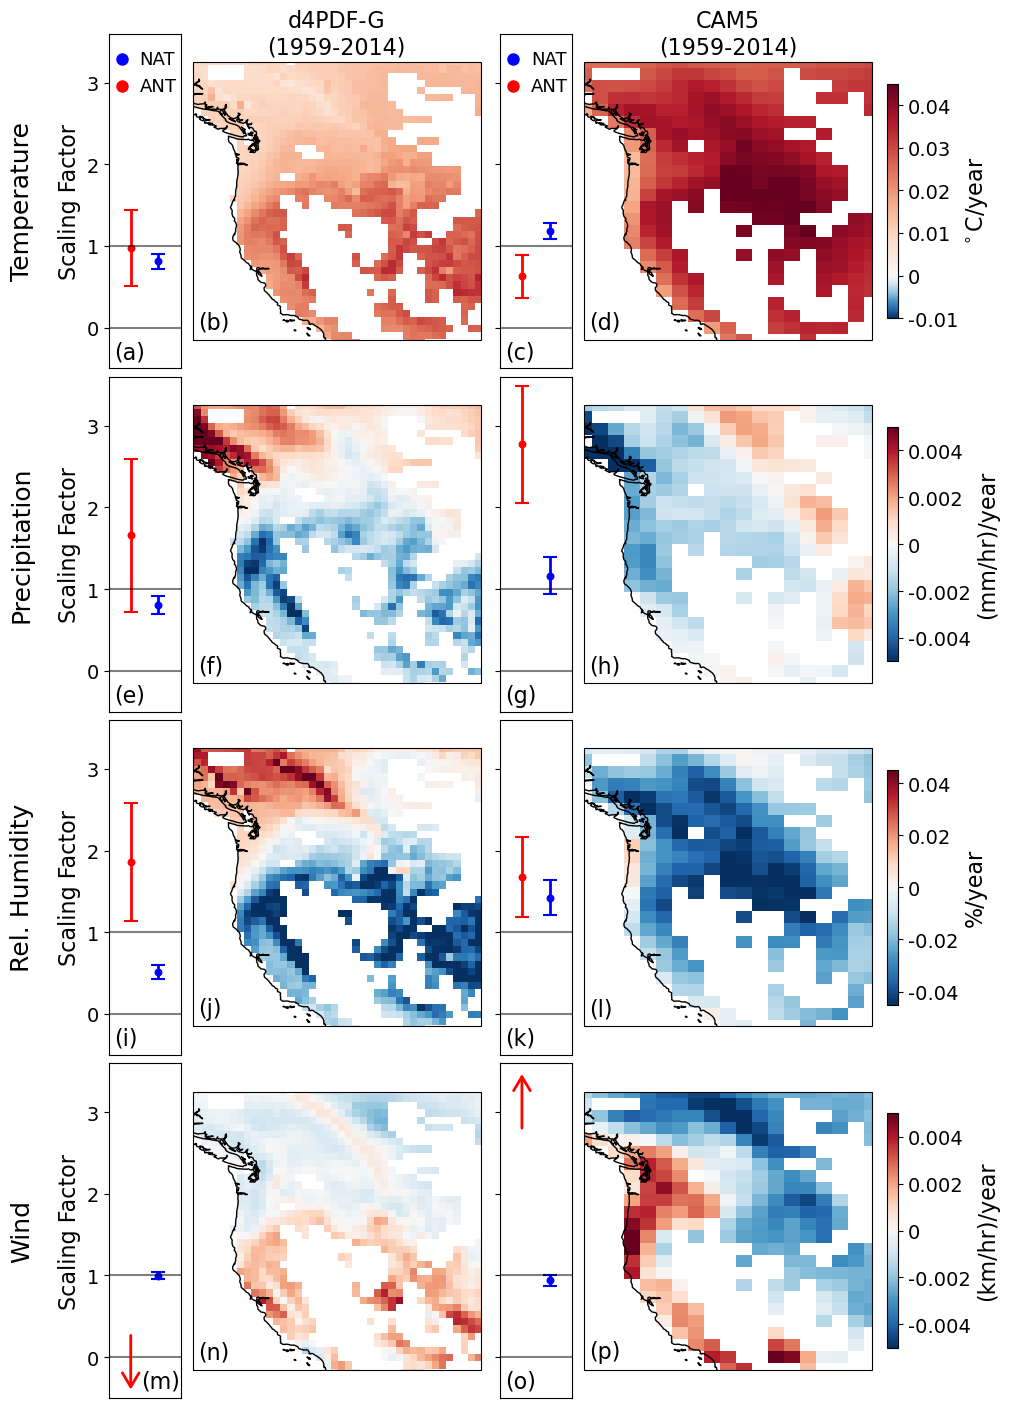

In [5]:
'''
Scaling factors + maps for d4PDF
'''


font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

fig = plt.figure(figsize=(10,14),layout='constrained')
d4pdf_sf_axs,d4pdf_map_axs,cam5_sf_axs,cam5_map_axs = setup_figure()
cmap_ranges = {'temp':[-0.01,0.045],'precip':[-0.005,0.005],'rel. humidity':[-0.045,0.045],'wind':[-0.005,0.005]}
tick_labels = {'temp':[-0.01,0,0.01,0.02,0.03,0.04],'precip':[-0.004,-0.002,0,0.002,0.004],'rel. humidity':[-0.04,-0.02,0,0.02,0.04],'wind':[-0.004,-0.002,0,0.002,0.004]}
var_names = {'temp':'Temperature','precip':'Precipitation','rel. humidity':'Rel. Humidity','wind':'Wind'}
units = {'temp':'$^\circ$C/year','precip':'(mm/hr)/year','rel. humidity':'%/year','wind':'(km/hr)/year'}

for model in ['d4PDF-G','CAM5']:
    
    if model == 'd4PDF-G':
        beta_est_df = pd.read_csv('/home/queenle/fire_attribution/result_files/d4pdf_beta_est_trunc_60_1951_2021.csv')
        beta_est_df.set_index('type',inplace=True)

        ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_ensMean.nc')
        NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_NAT_ensMean.nc')    
        ANT_ds = ALL_ds - NAT_ds
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        
        ANT_ds = ANT_ds.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        ANT_ds = ANT_ds.where(d4pdf_vege_mask>0)
        ANT_ds = ANT_ds.sel(time=slice('1959','2014'))
        ANT_ds = ANT_ds.where(~era5_da.isnull())
        
        var_dict = {'temp':'ta','precip':'precipi','rel. humidity':'rha','wind':'wind'}
        factor_axs = d4pdf_sf_axs
        map_axs = d4pdf_map_axs
    else:
        beta_est_df = pd.read_csv('/home/queenle/fire_attribution/result_files/cam5_beta_est_trunc_30_1959_2014.csv')
        beta_est_df.set_index('type',inplace=True)

        ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_All_ensMean.nc')
        NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_Nat_ensMean.nc')    
        ANT_ds = ALL_ds - NAT_ds
        ANT_ds = ANT_ds.rename({'lon':'longitude','lat':'latitude'})
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        
        ANT_ds = ANT_ds.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        ANT_ds = ANT_ds.where(cam5_vege_mask>0)
        ANT_ds = ANT_ds.sel(time=slice('1959','2014'))
        ANT_ds = ANT_ds.where(~era5_da.isnull())
        
        var_dict = {'temp':'tasmax','precip':'pr','rel. humidity':'rh','wind':'wind'}
        factor_axs = cam5_sf_axs
        map_axs = cam5_map_axs
        
    for i,var in enumerate(['temp','precip','rel. humidity','wind']):

        # PLOT SCALING FACTOR
        ax = factor_axs[i]

        ax.scatter(0.05, beta_est_df[var].loc['best_nat'],color='blue',marker='.',s=88,label='NAT' if var == 'temp' else '')
        ax.scatter(0.05, beta_est_df[var].loc['low_nat'],color='blue',marker='_',s=88)
        ax.scatter(0.05, beta_est_df[var].loc['high_nat'],color='blue',marker='_',s=88)
        ax.vlines(0.05,beta_est_df[var].loc['low_nat'],beta_est_df[var].loc['high_nat'],color='blue',linewidth=2)
        if model == 'd4PDF-G':
            ax.set_ylabel('Scaling Factor',fontdict=font)
            font['size']=18
            ax.text(-1.2,0.5,var_names[var],rotation='vertical',transform=ax.transAxes,fontdict=font,horizontalalignment='center',verticalalignment='center')
            font['size']=16
            
        if var == 'wind':
            if model == 'd4PDF-G':
                ax.annotate('', xy=(-0.05, 0.3),xycoords='data',xytext=(-0.05, -0.43),\
                            textcoords='data',arrowprops=dict(arrowstyle= '<-, head_width=.6, head_length=1',color='red',lw=2,ls='-'))
            else:
                ax.annotate('', xy=(-0.05, 2.77),xycoords='data',xytext=(-0.05, 3.5),\
                            textcoords='data',arrowprops=dict(arrowstyle= '<-, head_width=.6, head_length=1',color='red',lw=2,ls='-')) 
        else:
            ax.scatter(-0.05, beta_est_df[var].loc['best_ant'],color='red',marker='.',s=88,label='ANT' if var == 'temp' else '')
            ax.scatter(-0.05, beta_est_df[var].loc['low_ant'],color='red',marker='_',s=88)
            ax.scatter(-0.05, beta_est_df[var].loc['high_ant'],color='red',marker='_',s=88)
            ax.vlines(-0.05,beta_est_df[var].loc['low_ant'],beta_est_df[var].loc['high_ant'],color='red',linewidth=2)

        ax.set_ylim(-0.5,3.6)
        ax.set_xlim(-0.13,0.13)
        ax.hlines(0,-1,4,color='black',alpha=0.5)
        ax.hlines(1,-1,4,color='black',alpha=0.5)

        # Trend MAP
        ANT_da = ANT_ds[var_dict[var]]

        if var == 'temp':
            im = xr.apply_ufunc(get_linregress_slope, ANT_da, input_core_dims=[["time"]], vectorize = True).plot(ax=map_axs[i],norm=colors.TwoSlopeNorm(0, vmin=cmap_ranges[var][0], vmax=cmap_ranges[var][1]),cmap='RdBu_r',add_colorbar=False)
            if model == 'CAM5':
                cb = fig.colorbar(im,shrink=0.7)
                cb.ax.set_yscale('linear')
                font['size'] = 16
                cb.set_label(label=units[var],fontdict=font)
                font['size'] = 14
                cb.set_ticks(tick_labels[var])
                cb.set_ticklabels([str(val) for val in tick_labels[var]],fontdict=font)
        else:
            im = xr.apply_ufunc(get_linregress_slope, ANT_da, input_core_dims=[["time"]], vectorize = True).plot(ax=map_axs[i],vmin=cmap_ranges[var][0],vmax=cmap_ranges[var][1],cmap='RdBu_r',add_colorbar=False)
            if model == 'CAM5':
                cb = fig.colorbar(im,shrink=0.7)
                cb.set_ticks(tick_labels[var])
                cb.set_ticklabels([str(val) for val in tick_labels[var]],fontdict=font)
                font['size'] = 16
                cb.set_label(label=units[var],fontdict=font)
                font['size'] = 14
                

for ax in d4pdf_sf_axs:
    ax.set_yticks([0,1,2,3])
    font['size'] = 14
    ax.set_yticklabels(['0','1','2','3'],fontdict=font)
    font['size'] = 16

for ax in cam5_sf_axs:
    ax.set_yticks([0,1,2,3])
    #font['size'] = 14
    #ax.set_yticklabels(['0','1','2','3'],fontdict=font)
    #font['size'] = 16

d4pdf_sf_axs[0].legend(frameon=False,fontsize=13, markerscale=1.7,handletextpad=0, bbox_to_anchor=(1.17, 1))
cam5_sf_axs[0].legend(frameon=False,fontsize=13, markerscale=1.7,handletextpad=0, bbox_to_anchor=(1.17, 1))

d4pdf_map_axs[0].set_title('d4PDF-G\n(1959-2014)',fontdict=font)
cam5_map_axs[0].set_title('CAM5\n(1959-2014)',fontdict = font)

subplot_labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)',
                  '(i)','(j)','(k)','(l)','(m)','(n)','(o)','(p)']
for i in range(4):
    if i == 3:
        d4pdf_sf_axs[i].text(0.45,0.03,subplot_labels[4*i],transform=d4pdf_sf_axs[i].transAxes,fontdict=font)
    else:
        d4pdf_sf_axs[i].text(0.08,0.03,subplot_labels[4*i],transform=d4pdf_sf_axs[i].transAxes,fontdict=font)
        
    d4pdf_map_axs[i].text(0.02,0.04,subplot_labels[4*i+1],transform=d4pdf_map_axs[i].transAxes,fontdict=font)
    cam5_sf_axs[i].text(0.08,0.03,subplot_labels[4*i+2],transform=cam5_sf_axs[i].transAxes,fontdict=font)
    cam5_map_axs[i].text(0.02,0.04,subplot_labels[4*i+3],transform=cam5_map_axs[i].transAxes,fontdict=font)
    

#plt.savefig('/home/queenle/fire_attribution/figures/Figure6.png',dpi=300,transparent=False, bbox_inches='tight', pad_inches=0.35)


In [17]:
'''
MAIN function for performing optimal fingerprinting using d4pdf and ERA5
'''

trunc_dict = {'d4pdf':'60','cam5':'30'}
for model in ['d4pdf','cam5']:
    
    
    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        start,end = ('1959','2014')
        vege_mask = cam5_vege_mask
        var_dict = {'temp':['tasmax','mx2t'],'precip':['pr','tp'],'rel. humidity':['rh','min_rh'],'wind':['wind','wind']}

    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        start,end = ('1951','2021')
        vege_mask = d4pdf_vege_mask
        var_dict = {'temp':['ta','mx2t'],'precip':['precipi','tp'],'rel. humidity':['rha','min_rh'],'wind':['wind','wind']}

    beta_est_dict = {'type':['best_ant','low_ant','high_ant','best_nat','low_nat','high_nat']}

    for i,var in enumerate(['temp','precip','rel. humidity','wind']):
        
        print(var)
        
        ax = axs[i]

        beta_est = fingerprint(model, box, var_dict[var], vege_mask, start, end, scen_dict)
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]
        
        beta_est_dict[var] = [best_1,low_1,up_1,best_2,low_2,up_2]
        

    model_df = pd.DataFrame.from_dict(beta_est_dict)
    
    model_df.to_csv('/home/queenle/fire_attribution/result_files/'+model+'_beta_est_trunc_'+trunc_dict[model]+'_'+start+'_'+end+'.csv')
    

In [10]:
def fingerprint(model, box, var_list, vege_mask, start_year, end_year, scen_dict):

    IDL.retall

    print(var_list[0])
    
    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(model, var_list[0], scen_dict['ALL'], box, vege_mask, start_year, end_year)
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(model, var_list[0], scen_dict['NAT'], box, vege_mask, start_year, end_year)

    print('getting obs')
    data_obs = get_obs_data(model, box, var_list[1], vege_mask, start_year, end_year)
    print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    if model == 'cam5':
        data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))
        trunc = 30
    else:
        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))
        trunc = 60
        
    print('got arrays')

    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    
    '''
    print(np.isnan(data_obs).any())
    print(np.isnan(data_scen).any())
    print(np.isnan(data_noise_1).any())
    print(np.isnan(data_noise_2).any())
    print(np.isnan(trunc).any())
    '''
    
    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc")

    beta_est = IDL.beta_est
    
    #print(scan_beta_est)
    
    return beta_est

In [4]:
def get_obs_data(model, box, var, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
        era5_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_inputs_6month_fire_season_cam5_resolution.nc')
        era5_da = era5_ds[var]
    else:
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
        era5_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_inputs_6month_fire_season_d4pdf_resolution.nc')
        era5_da = era5_ds[var]

    if box != 'full':
        era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    era5_da = era5_da.where(vege_mask>0)
        
    era5_da = era5_da.sel(time=slice(start_year,end_year))
    era5_da = era5_da.where(~model_da.isnull())
    
    era5_da = era5_da.stack(pixel=("latitude", "longitude"))
    era5_da = era5_da.dropna("pixel", how="all")        
    
    array = era5_da.values.flatten()
        
    return(array)


In [5]:
def get_noise(model,var,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
                
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            mem_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_'+scen+'_run'+number+'_1959-2018.nc')
            mem_da = mem_ds[var]
        elif model == 'd4pdf':
            mem_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_'+scen+'_m'+number+'_1951-2021.nc')
            mem_da = mem_ds[var]
            
        if box != 'full':
            if model == 'd4pdf':
                mem_da = mem_da.drop(['longitude','latitude'])
            mem_da = mem_da.rename({'lon':'longitude','lat':'latitude'})
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [6]:
def get_mean_and_noise(model, var, scen, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        ens_mean_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_'+scen+'_ensMean.nc')
        ens_mean = ens_mean_ds[var]
    else:
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        ens_mean_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_'+scen+'_ensMean.nc')
        ens_mean = ens_mean_ds[var]
    
    if box != 'full':
        if model == 'cam5':
            ens_mean = ens_mean.rename({'lon':'longitude','lat':'latitude'})
        
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(model,var,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()
    
    return((ens_mean_array, np.array(noise)))


In [17]:
def plot_result(scan_beta_est, ax):

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        ax.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        ax.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        ax.vlines(j+3,low_2,up_2,colors=['blue'])
        ax.vlines(j+3,low_1,up_1,colors=['red'])

        ax.axhline(0,-0.5,1.5)
        ax.axhline(1,-0.5,1.5)

    ax.legend()
    ax.set_ylim(-1,4)

    #plt.title('ERA5/d4pdf 6month fire season FWI OF (1951-2021)')
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    #plt.show()
    #plt.close(fig)
    

In [ ]:
def fire_season(month):
    return (month >= 5) & (month <= 10)

for scen in ['HPB','HPB_NAT']:
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        BS_wind_daily = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/BC_wind/BC_WIND_'+scen+'_m'+number+'_1951-2021.nc')
        months_selected = BS_wind_daily.sel(time=fire_season(BS_wind_daily['time.month']))
        fire_season_BC_wind = months_selected.resample(time ='A').mean('time')
        
        
        input_ds = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_'+scen+'_m'+number+'.nc')
        old_wind = input_ds.wind
        input_ds = input_ds.drop('wind')
        input_ds = input_ds.assign(wind=fire_season_BC_wind)
        
        input_ds.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_'+scen+'_m'+number+'_1951-2021.nc')
    
        

In [ ]:
old_d4pdf_inputs = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_HPB_ensMean.nc')
new_d4pdf_inputs = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_ensMean.nc')

old_mean = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/inputs/FWI_inputs_HPB_ensMean.nc')


for var in ['ta','precipi','rha','wind']:
    
    old_d4pdf_inputs[var].mean(['lat','lon']).plot(label='old temp')
    new_d4pdf_inputs[var].mean(['latitude','longitude']).plot(label='new temp')
    
    plt.show()
    plt.close()